# Alternative Data Types
In the previous section, we discussed how some types of outcome variable are unsuitable for modelling with a normal distribution. We demonstrated the issues when using a *binary* outcome, but this was just one example. To give a better sense of the variety of data we may collect, and how it can be modelled probabilistically, this part of the lesson will introduce some different types of data and their associated distributions. This provides the starting point for considering how these different types can be modelled.

## Distributions of Alternative Data Types 
We will work through some of the most commonly-used probability distributions and the types of data they are associated with. We start from the perspective of the *distribution* because we require a probability distribution in order to actually model the data. In all cases, remember that the distribution is an *idealised* representation of reality. Some of these distributions have more control over their shape and some have less, meaning that some can be more flexibly applied to data than others. In the same way that not all continuous data will fit a normal distribution, not all real world data will fit these distributions. However, they all represent that starting point for moving beyond the normal linear model for cases where it is not appropriate.

When getting to grips with these distributions, it can be useful to see how they are affected by their parameters. There is an excellent interactive website available [here](https://probabilityplayground.com/) that allows you to select a distribution and play around with the parameter values to see how it affects the shape. You may find this helpful when trying to understand how these distributions work.

### The Bernoulli Distribution
The Bernoulli[^foot-1] distribution can be used as a model of *binary* data. It is defined very simply: for a random variable $y$ that can take on a value of either 1 or 0 we have

$$
\begin{align*}
    P(y=1) &= p      \\
    P(y=0) &= 1 - p. \\
\end{align*}
$$

As such, the Bernoulli distribution only has one parameter, called $p$, that gives the probability of a value of 1. This is often referred to as the probability of a "success" [^foot-2]. The expected value and variance are then given by

$$
\begin{align*}
    E(y)          &= p         \\
    \text{Var}(y) &= p(1 - p). \\
\end{align*}
$$

[^foot-1]: Named after the mathematician [Jacob Bernoulli](https://en.wikipedia.org/wiki/Jacob_Bernoulli).
[^foot-2]: This can be an unfortunate convention, especially when applying models like this to experiments such as counting each rat that died under an experimental treatment as a "success". 

A plot of the Bernoulli distribution is given below for $p = 0.4$.

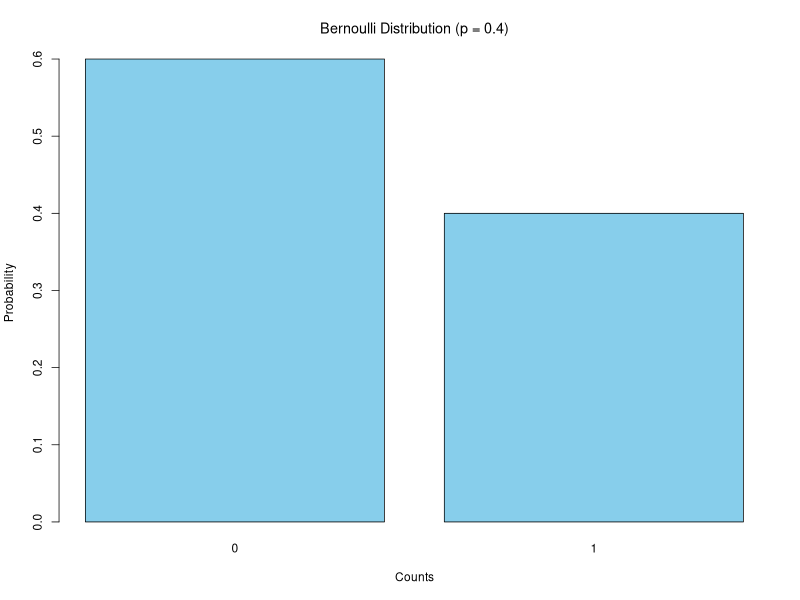

In [1]:
x <- seq(0,1)
y <- dbinom(x, size=1, prob=0.4)
barplot(y, 
        names.arg=x,
        col='skyblue',
        xlab="Counts", 
        ylab="Probability", 
        main=expression(paste("Bernoulli Distribution (", p, " = 0.4)")))

To see how the Bernoulli distribution could be used in conjunction with a continuous predictor variable, consider the example from earlier of failures in an industrial process in relation to temperature. As temperature goes up, we expect the probability of failure to also go up. Much like the normal linear model, we are modelling the expected value of the outcome as conditional on the value of the predictor. The only difference is that this expected value is the probability of "success". This results in the model shown in [](#fig-binary-bernoulli-3D).

```{figure} images/binary_bernoulli_3D.gif
:label: fig-binary-bernoulli-3D
:alt: Example of a Bernoulli probability model for a binary outcome and a continuous predictor.
:align: center

Example of a Bernoulli probability model for a binary outcome and a continuous predictor.
```


Of importance is that, because probability does not simply increase as a straight line, we end up with a different shape compared to a regression line. This is because probability is bounded between 0 and 1 and must therefore flatten-off as it approaches either extreme. This S-shaped curve will become a familiar sight as we progress.

```{admonition} Bernoulli in Practice
Here are some examples of experiments from psychology and cognitive neuroscience that could be modelled using a Bernoulli distribution:
- Whether a subject detected a faint visual stimulus on a trial.
- Whether a memory item was recalled correctly or not.
- Whether a subject made a correct response on a single trial.
```

### The Binomial distribution
The binomial distribution is closely related to the Bernoulli distribution. Rather than being defined in relation to a binary outcome, the binomial distribution relates to *counts*. Specifically, the count of the number of successes in a series of trials where each outcome is binary. For instance, the typical example is flipping a coin a number of times. Each time the coin is flipped, the outcome is binary (either *heads* or *tails*). If we flip the coin 10 times we can take a count of the number of heads, and that count could be modelled using the binomial distribution.

Because this definition is more complex than the Bernoulli case, the probability mass of the binomial is also more complex. For a random variable $y$, the probability that the count is equal to $k$ is given by

$$
P(y = k) = {n\choose k}p^{k}(1-p)^{n-k},
$$

where $p$ is the probability of success for a single trial and $n$ is the number of trials. The quantity ${n\choose k}$ is known as the [binomial coefficient](https://en.wikipedia.org/wiki/Binomial_coefficient), hence the name of the distribution. The expected value and variance are then given by

$$
\begin{align*}
    E(y)          &= np \\
    \text{Var}(y) &= np(1-p) \\
\end{align*}
$$

Because $n$ is typically fixed, these quantities rely solely on the probability of success $p$. An example of a binomial distribution for $n = 10$ and $p = 0.4$ is shown below.

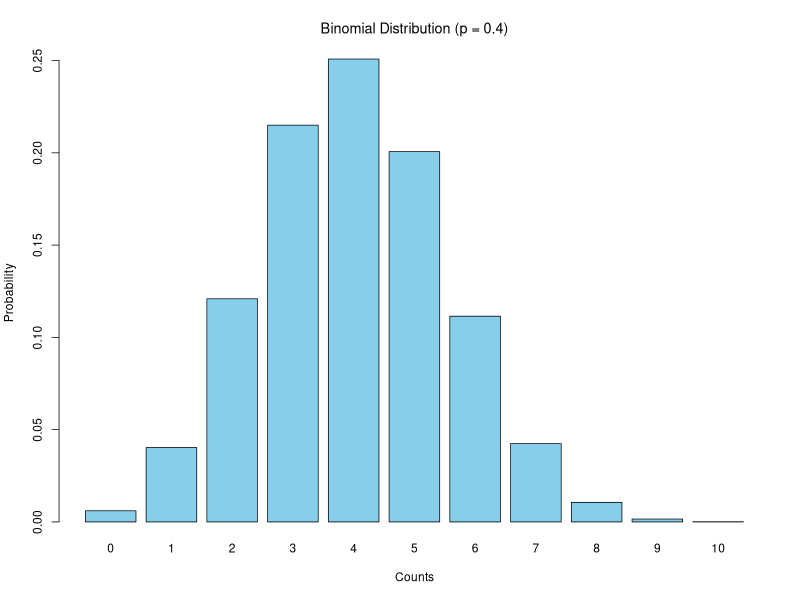

In [2]:
x <- seq(0,10)
y <- dbinom(x, size=10, prob=0.4)
barplot(y, 
        names.arg=x,
        col='skyblue',
        xlab="Counts", 
        ylab="Probability", 
        main=expression(paste("Binomial Distribution (", p, " = 0.4)")))

We can easily connect this with the coin flipping example. If you flipped a coin 10 times in a row and the coin was biased so it only produces heads 40% of the time, what's the most likely number of heads you would get? The obvious answer is 4 heads, which is exactly what the mean of the distribution shows. Importantly, we cannot get less than 0 heads, or more than 10 heads, and so the distribution is bounded by these values. Furthermore, the distribution is *discrete*, so it only ever produces whole numbers as we cannot have fractional counts.

As a more applied example, imagine we were investigating the same industrial process as used in the example above. However, this time we can only run the manufacturing process in batches of 20 at a given temperature. Our outcome variable is then a count of the number of defective products within a single batch. If we repeat this process 5 times for each temperature, we could then model the change in average count per batch as temperature increases using a binomial distribution. Because $n = 20$ is fixed, this depends only upon the probability of "success" and is shown in [](#fig-count-binomial-3D). 

```{figure} images/count_binomial_3D.gif
:label: fig-count-binomial-3D
:alt: Example of a binomial probability model for a count outcome and a continuous predictor.
:align: center

Example of a binomial probability model for a count outcome and a continuous predictor. The raw data are defined by the red markers, with each distribution defined along the $y$-axis for each value of temperature.
```

If we had used a normal distribution here, not only would the count extend below 0 and above 20, but values in between the counts would also have some non-zero probability. Note that the Bernoulli distribution is actually a special case of the binomial, with $n = 1$.

```{admonition} Binomial in Practice
Here are some examples of experiments from psychology and cognitive neuroscience that could be modelled using a binomial distribution:
- Number of correct responses out of 20 trials at each stimulus intensity.
- Number of remembered words out of a fixed list of 15.
- Number of successfully inhibited responses out of 30 stop-signal trials.
```

### The Poisson Distribution
The Poisson distribution[^foot-3], is another discrete probability distribution associated with *count* data. In comparison to the binomial distribution, the Poisson is most closely associated with counting something within a discrete interval of time. For instance, standing on a street corner and counting the number of red cars that pass within 10 minutes. Because of this, the Poisson distribution has a lower bound of 0, but no upper bound, as there is no maximum limit on the number of occurrences in the same way that there is a maximum number of trials in the binomial distribution. 

For a random variable $y$ that is Poisson distributed, the probability that the count is equal to $k$ is given by

$$
P(y = k) = \frac{\lambda^{k}e^{-\lambda}}{k!},
$$

where $\lambda$ is the average number of occurrences and is the *only* parameter of the Poisson distribution. As such, $\lambda$ parameterises both the expected value and variance

$$
\begin{align*}
    E(y)          &= \lambda \\
    \text{Var}(y) &= \lambda. \\
\end{align*}
$$

This means that as the average count grows, so too does the width of the distribution. An example Poisson distributuon with $\lambda=4$ is given below.

[^foot-3]: Named after the mathematician [Siméon Denis Poisson](https://en.wikipedia.org/wiki/Sim%C3%A9on_Denis_Poisson).

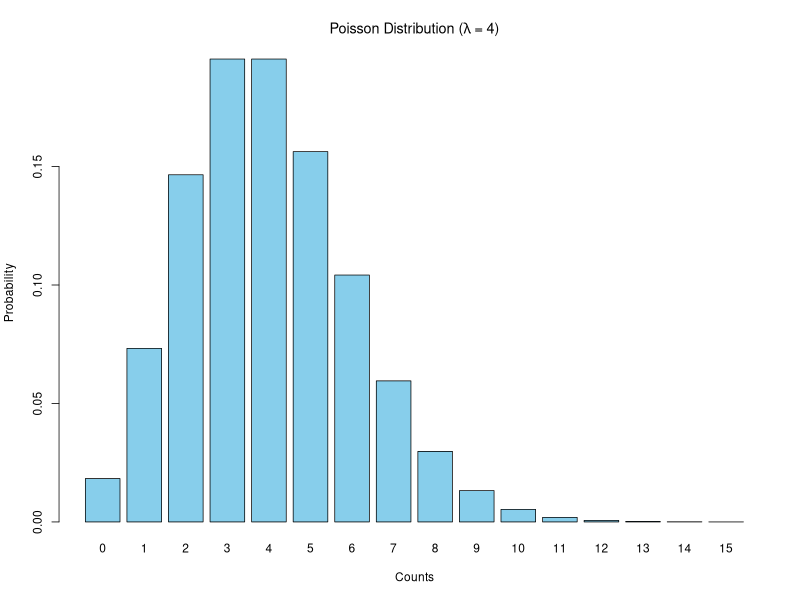

In [3]:
x <- seq(0,15)
y <- dpois(x, lambda=4)
barplot(y, 
        names.arg=x,
        col='skyblue',
        xlab="Counts", 
        ylab="Probability", 
        main=expression(paste("Poisson Distribution (", lambda, " = 4)")))


We can again use our example of counting defective items to illustrate a model that uses the Poisson distribution. This time, rather than counting the number of defective items in a fixed batch, we simply observe the manufacturing processes for a set amount of time and count the number of defective items. For instance, say we watch the process for 10 minutes. We then repeat this 5 times for each temperature setting. The Poisson model is shown in [](#fig-count-poisson-3D).

```{figure} images/count_poisson_3D.gif
:label: fig-count-poisson-3D
:alt: Example of a Poisson probability model for a count outcome and a continuous predictor.
:align: center

Example of a Poisson probability model for a count outcome and a continuous predictor. The raw data are indicated by the red markers, with each distribution defined along the $y$-axis for each value of temperature.
```

Notice that as the average count goes up, so too does the width of the distribution. This is a clear demonstration of how the Poisson distribution is only controlled by a single parameter that affects both its *mean* but also its *variance*. Also notice that the change in the Poisson mean is not a straight line, rather it curves upwards. So, again, we are seeing that when we move to a different distribution we cannot necessarily expect the relationship to remain straight. This is particularly true when the outcome is bounded, because the relationship needs to flatten-off near that edges of the boundary. Again, if we had used a Gaussian distribution, we would have predicted counts that extend below 0 and non-zero probability for fractional values.

```{admonition} Poisson in Practice
Here are some examples of experiments from psychology and cognitive neuroscience that could be modelled using a Poisson distribution:
- Number of button presses during a 30-second interval.
- Number of spontaneous blinks during a one-minute period.
- Number of seizures or other relatively rare events within a fixed observation period.
```

### The Gamma Distribution
The final distribution we will consider is the gamma distribution. Unlike the distributions above, the gamma distribution is not discrete, rather, it is an alternative to a normal distribution for *continuous* outcome variables that are *skewed*. The gamma distributions is shaped by two parameters called $\alpha$ and $\theta$. $\alpha$ is known as the *shape* parameter and $\theta$ is known as the *scale* parameter. The probability density for a random variable $y$ is then given by

$$
    P(y) = \frac{1}{\Gamma(\alpha)\theta^{\alpha}}y^{\alpha-1}e^{-y/\theta},
$$

where $\Gamma(\alpha)$ is the [gamma function](https://en.wikipedia.org/wiki/Gamma_function) (hence the name) and the distribution has an expected value and variance of

$$
\begin{align*}
    E(y)          &= \alpha\theta \\
    \text{Var}(y) &= \alpha\theta^{2}.
\end{align*}
$$

Like some of the other examples, the mean and variance are therefore dependent on the same parameters and cannot be specified independently. The gamma distribution is also *positive only*, so cannot model any variables with a range that extends $< 0$. An example of a gamma distribution with $\alpha = 2$ and $\theta = 2$ is given below

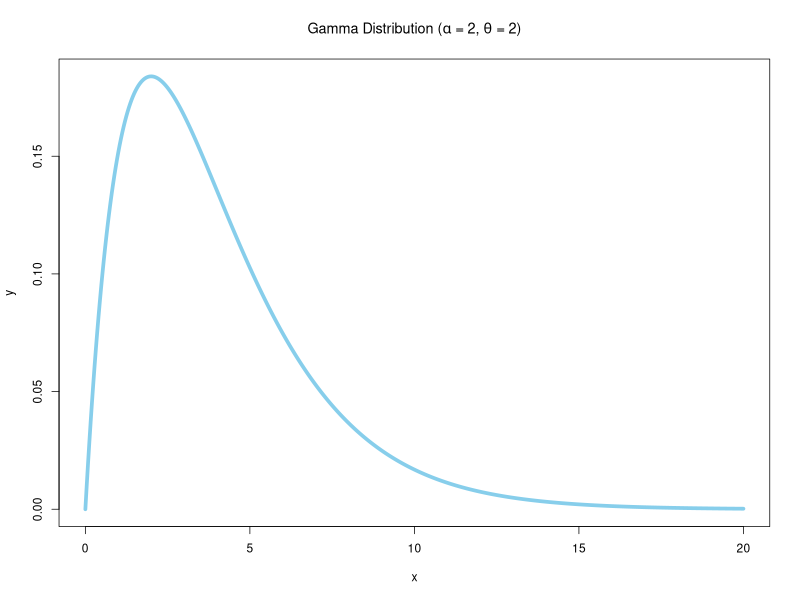

In [4]:
alpha <- 2
theta <- 2
x     <- seq(0, 20, length=500)
y     <- dgamma(x, shape=alpha, scale=theta)
plot(x, y,
  type = "l",
  lty  = 1,
  lwd  = 5,
  col  = "skyblue",
  main = expression(paste("Gamma Distribution (", alpha, " = 2, ",  theta," = 2)")))

The clearest example for using a gamma distribution comes from reaction time measurements, which tend to be skewed and are bounded below by 0. For instance, we could model average reaction time as a function of age using the gamma distribution. This is illustrated in [](#fig-cont-gamma-3D).

```{figure} images/cont_gamma_3D.gif
:label: fig-cont-gamma-3D
:alt: Example of a gamma probability model for a skewed outcome and a continuous predictor.
:align: center

Example of a gamma probability model for a skewed outcome and a continuous predictor.
```

Notice that as the mean changes, so too does the variance. Again, because these aspects of the distribution are tied to the same parameters, they cannot be separated.

```{admonition} Gamma in Practice
Here are some examples of experiments from psychology and cognitive neuroscience that could be modelled using a gamma distribution:
- Reaction time on correct trials.
- Time required to complete a cognitive task.
- Duration of an eye movement or dwell time in a region of interest.
```

## Alternative Distribution Parameterisations
Although we have now characterised a number of alternative distributions for different data types, we need to be mindful of how these distributions are *parameterised*. In general, we need to consider:
- how many parameters the distribution has
- how those parameters control the shape of the distribution
- how those parameters can be interpreted

For the normal distribution, we know it has *two* parameters that control the *centre* ($\mu$) and *width* ($\sigma^2$) of the distribution. These can be interpreted as the *average value* of the outcome and its *average spread*. This makes the normal distribution very easy to use and understand because its mean and variance are directly control by a single parameter each. We can therefore directly model the mean and the variance, as we saw last semester.

Unfortunately, alternative distributions are not always so simple to use. For example, the Poisson distribution is controlled by a single parameter $\lambda$. This is interpreted as the average count which, despite the distribution being discrete, is allowed to be any positive number, fractional or whole. We can model this parameter, however, we need to make sure that our model only ever produces *positive* values. Furthermore, this mean function will also be the variance function, because the parameter $\lambda$ controls both. So this is suddenly more complex and fiddly than the normal distribution.

As another example, the gamma distribution is parameterised by both a *shape* and a *scale* parameter. These values can be difficult to understand and the expected value of the gamma distribution depends upon their product. This means that there are *two* values that need to be modelled as part of the mean function. Like the Poisson distribution, the variance also depends upon their value, conflating the mean and variance functions. As we will see, the gamma distribution is often re-expressed into a single value for the mean and a single *dispersion* parameter for the variance. This is an additional step precisely because the gamma distribution is not as amenable to modelling as other distributions.

The conclusion for now is that other distributions are available for different data types. These distributions will often be more sensible than the normal distribution as they are defined to be discrete, bounded above and below as needed, and do not assume that the data are symmetrically distributed around the mean. In principle, this will lead to much more sensible models that can make more accurate inference and predictions. This is a good thing. However, actually using these distributions is more complex than using the normal distribution and is going to require some additional effort.

:::{tip .simple icon=false} What You Now Know
In this section, we have discussed several alternative distributions that are suitable for data where the normal distribution would be inappropriate. After reading this section, you should have a good sense of:
- The Bernoulli distribution:
    - Suitable for binary outcome variables and parameterised by the probability of "success" on a single trial.
- The binomial distribution:
    - Suitable for count outcome variables that result from a series of binary trials. Parameterised by the number of trials and the probability of "success" on a single trial.
- The Poisson distribution:
    - Suitable for count outcome variables that result from a fixed interval of observation. Parameterised by the average count during the interval.
- The gamma distribution:
    - Suitable for continuous outcome variables that are skewed. Parameterised by a *shape* and *scale* parameter.
- The general idea that, much like the normal distribution, it is the parameters of these distributions that we seek to model to form the mean and variance functions.
- The issue that many of these distributions do not have a simple parameterisation and sometimes do not have independent specifications of the mean and variance.
- The issue that the value of these parameters is often restricted and thus further restrictions must be placed on the model.
:::